In [1]:
import gymnasium as gym
import torch

from gymnasium.wrappers import TimeLimit

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import (
    DummyVecEnv, 
    VecNormalize,
    VecFrameStack, 
    VecTransposeImage
)

from stable_baselines3.common.monitor import Monitor

from src.wrapper.pendulum_wrapper import ResizeObservation
from src.wrapper.pendulum_wrapper import ResizeObservation
from src.wrapper.visual_wrapper import VisualWrapper, GrayscaleObservation, MountainCarRewardEngineering


In [2]:
episode_timesteps=1000
total_timesteps = 10_000_000
parallel_envs = 2
n_steps = 1024
save_model_every_steps = n_steps
eval_n_step = n_steps * 2

image_height = 256
image_width = 256

# Define the hyperparameters for PPO
ppo_hyperparams = {
    "learning_rate": 2e-4,  # The step size used to update the policy network. Lower values can make learning more stable.
    "n_steps": n_steps,  # Number of steps to collect before performing a policy update. Larger values may lead to more stable updates.
    "batch_size": 512,  # Number of samples used in each update. Smaller values can lead to higher variance, while larger values stabilize learning.
    "gamma": 0.9,  # Discount factor for future rewards. Closer to 1 means the agent places more emphasis on long-term rewards.
    "gae_lambda": 0.9,  # Generalized Advantage Estimation (GAE) parameter. Balances bias vs. variance; lower values favor bias.
    "n_stacked_frame": 8, # The number of stacked frame feed forward to the policy model
    "clip_range": 0.2,  # Clipping range for the PPO objective to prevent large policy updates. Keeps updates more conservative.
    "use_sde": False,
    "sde_sample_freq": 4,
    "ent_coef": 0.01,
    "n_epochs": 10
    # "learning_rate": get_linear_fn(1e-3, 5e-6, total_timesteps),  # Linear decay from
}

def make_env(seed, truncated=False):
    def _init():
        env = gym.make("MountainCarContinuous-v0", render_mode="rgb_array", goal_velocity=0.1)
        env = MountainCarRewardEngineering(env)
        env = Monitor(env)
        env = VisualWrapper(env)
        env = ResizeObservation(env, (image_height, image_width))
        env = GrayscaleObservation(env)
        env = TimeLimit(env, max_episode_steps=episode_timesteps)

        env.reset(seed=seed)
        return env  
    return _init

In [3]:
env = DummyVecEnv([make_env(0)])
env = VecFrameStack(env, n_stack=8)
env = VecTransposeImage(env)
env = VecNormalize(env, norm_obs=False, norm_reward=True, clip_obs=10.0)

In [4]:
obs = env.reset()
obs.shape

(1, 8, 256, 256)

In [5]:
import numpy as np

np.squeeze(obs).shape

(8, 256, 256)

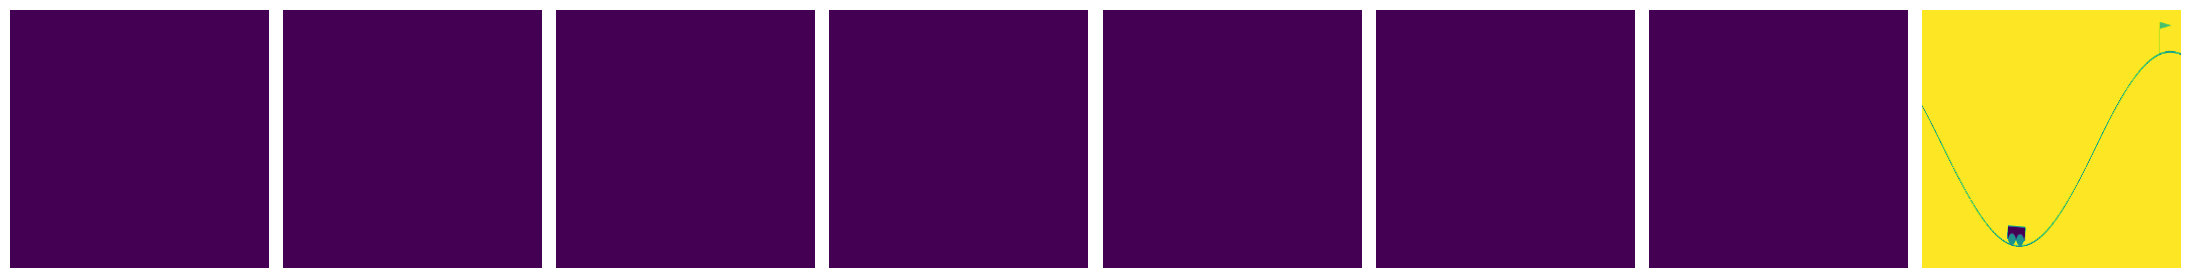

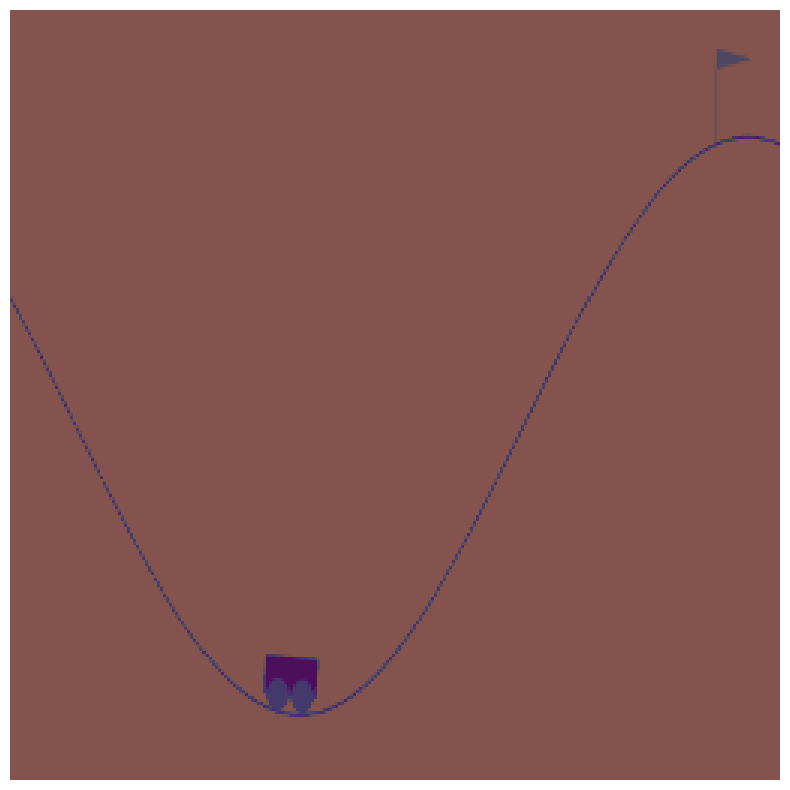

In [6]:
import matplotlib.pyplot as plt

def plot_obs(obs, title=""):
    n_frame = np.squeeze(obs).shape[0]
    fig, ax = plt.subplots(1, n_frame, figsize=(22, 10))

    for idx, tmp_obs in enumerate(np.squeeze(obs)):

        ax[idx].set_title(title)
        
        tmp_img = tmp_obs.astype(int)
        ax[idx].imshow(tmp_img, alpha=1)
        ax[idx].axis("off")

    plt.tight_layout()


def plot_obs_overlap(obs, title=""):
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    for idx, tmp_obs in enumerate(np.squeeze(obs)):

        ax.set_title(title)
        
        tmp_img = tmp_obs.astype(int)
        ax.imshow(tmp_img, alpha=0.3)
        ax.axis("off")

    plt.tight_layout()

plot_obs(obs)
plot_obs_overlap(obs)

In [7]:
import pandas as pd

log_fn = "../../run/ppo_vismountaintcar_default/ppo_vis_mountaincar_2_eval_default_seed_42.pkl"

with open(log_fn, "rb") as f:
    df = pd.read_pickle(f)
    df.reward = df.reward.apply(lambda x: x[0])

df

,state,action,reward,accumulated_reward
0,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,[[-0.42525005]],-0.019084,[-0.01908376]
1,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,[[-0.0004714504]],-0.001000,[-0.020083783]
2,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,[[0.48352683]],-0.024380,[-0.044463605]
3,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,[[-1.0]],-0.101000,[-0.14546362]
4,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,[[-1.0]],-0.101000,[-0.24646363]
...,...,...,...,...
994,[[[[255 255 255 255 255 255 255 255 255 255 25...,[[-0.37144634]],-0.013797,[-44.396812]
995,[[[[255 255 255 255 255 255 255 255 255 255 25...,[[-1.0]],-0.100000,[-44.49681]
996,[[[[255 255 255 255 255 255 255 255 255 255 25...,[[-1.0]],-0.100000,[-44.59681]
997,[[[[255 255 255 255 255 255 255 255 255 255 25...,[[0.8732295]],-0.076253,[-44.67306]


(1, 8, 256, 256)

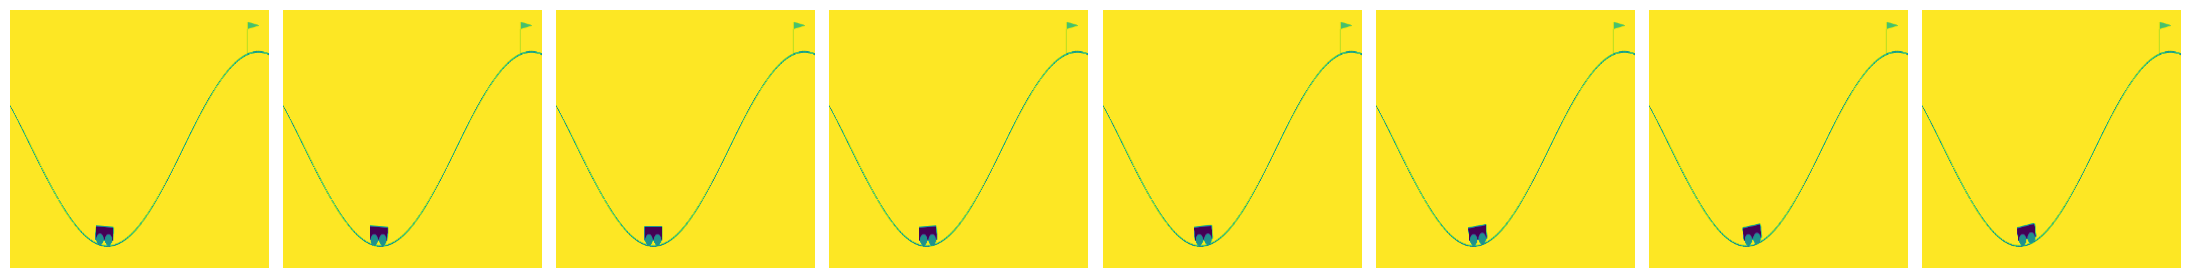

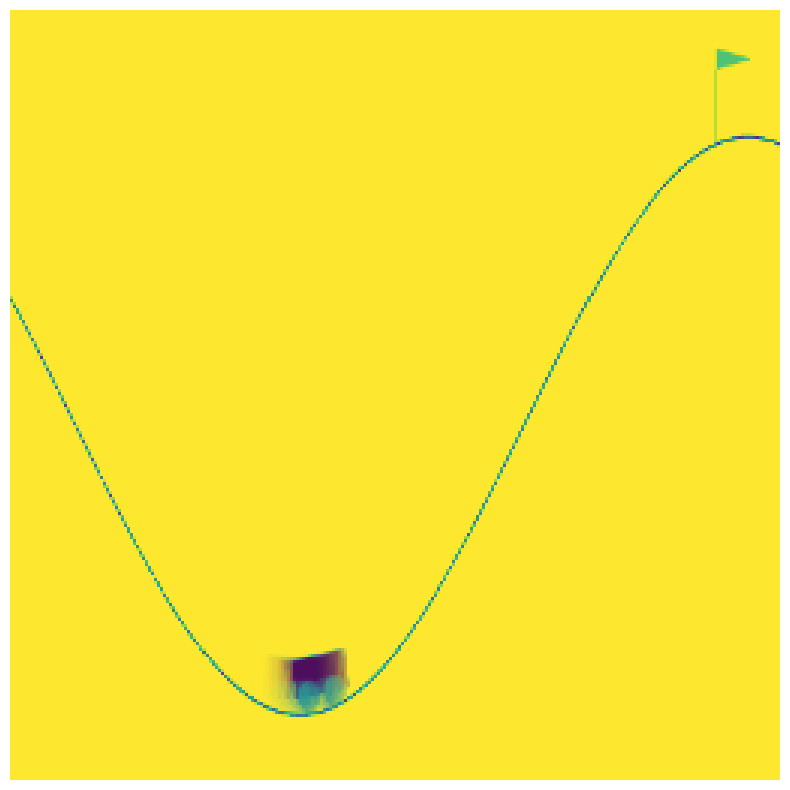

In [55]:
plot_obs(df.state[62])
plot_obs_overlap(df.state[62])
df.state[3].shape

In [9]:
df.iloc[df.reward.argmax()]

state                 [[[[255 255 255 255 255 255 255 255 255 255 25...
action                                                [[-0.0006285673]]
reward                                                             -0.0
accumulated_reward                                         [-29.473028]
Name: 651, dtype: object

In [10]:
df

,state,action,reward,accumulated_reward
0,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,[[-0.42525005]],-0.019084,[-0.01908376]
1,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,[[-0.0004714504]],-0.001000,[-0.020083783]
2,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,[[0.48352683]],-0.024380,[-0.044463605]
3,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,[[-1.0]],-0.101000,[-0.14546362]
4,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,[[-1.0]],-0.101000,[-0.24646363]
...,...,...,...,...
994,[[[[255 255 255 255 255 255 255 255 255 255 25...,[[-0.37144634]],-0.013797,[-44.396812]
995,[[[[255 255 255 255 255 255 255 255 255 255 25...,[[-1.0]],-0.100000,[-44.49681]
996,[[[[255 255 255 255 255 255 255 255 255 255 25...,[[-1.0]],-0.100000,[-44.59681]
997,[[[[255 255 255 255 255 255 255 255 255 255 25...,[[0.8732295]],-0.076253,[-44.67306]


(-1.2, 0.6)

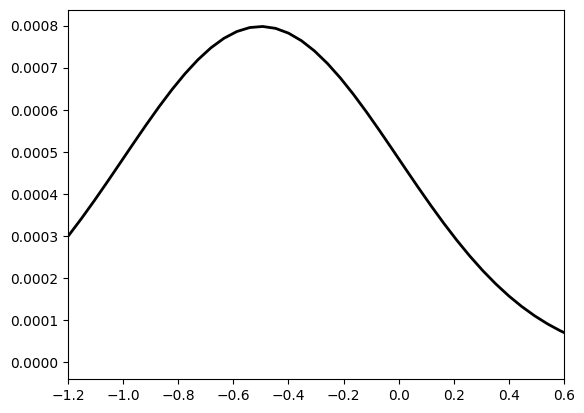

In [77]:
from scipy.stats import norm
from matplotlib import pyplot as plt

fig, ax = plt.subplots()

rv = norm(-0.5, 0.5)
rv.pdf(-0.6), rv.pdf(-0.3)

x = np.linspace(norm.ppf(0.01),
                norm.ppf(0.99), 100)
ax.plot(x, rv.pdf(x)*0.001, 'k-', lw=2, label='frozen pdf')
ax.set_xlim(-1.2, 0.6)

# Check model parameters

In [11]:
from src.model.cnn import CustomCNN
from run.ppo_vismountaintcar_default.args_parser import PPOHyperparameters

from torchsummary import summary



In [13]:
ppo = PPOHyperparameters(
    **ppo_hyperparams
)

policy_kwargs = dict(
            activation_fn=torch.nn.Tanh,
            net_arch=dict(pi=[128,64], vf=[128,64]),
            features_extractor_class=CustomCNN,
            features_extractor_kwargs=dict(features_dim=256, 
                                           n_channel=1, # gray scale image
                                           num_frames=ppo.n_stacked_frame)  # Adjust num_frames as needed
        )

# Create the PPO agent using the custom feature extractor
model = PPO(
    "CnnPolicy",
    env,
    policy_kwargs=policy_kwargs,
    learning_rate=ppo.learning_rate,
    n_steps=ppo.n_steps,
    batch_size=n_steps*parallel_envs,
    gamma=ppo.gamma,
    gae_lambda=ppo.gae_lambda,
    clip_range=ppo.clip_range,
    verbose=1,
    ent_coef=ppo.ent_coef,
    use_sde=ppo.use_sde,
    sde_sample_freq=ppo.sde_sample_freq,
    device=ppo.device,
)

summary(model.policy.features_extractor, obs[0].shape)

Using cuda device


/home/robosrv/huyhoang/visual_ppo_proj/stable-baselines-playground-thd/venv/lib/python3.11/site-packages/stable_baselines3/ppo/ppo.py:155: UserWarning: You have specified a mini-batch size of 2048, but because the `RolloutBuffer` is of size `n_steps * n_envs = 1024`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 1024
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=1024 and n_envs=1)
  warnings.warn(


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 127, 127]             584
              ReLU-2          [-1, 8, 127, 127]               0
            Conv2d-3           [-1, 16, 63, 63]           1,168
              ReLU-4           [-1, 16, 63, 63]               0
            Conv2d-5           [-1, 32, 31, 31]           4,640
              ReLU-6           [-1, 32, 31, 31]               0
            Conv2d-7           [-1, 32, 15, 15]           9,248
              ReLU-8           [-1, 32, 15, 15]               0
           Flatten-9                 [-1, 7200]               0
           Linear-10                  [-1, 256]       1,843,456
             ReLU-11                  [-1, 256]               0
Total params: 1,859,096
Trainable params: 1,859,096
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 2.00
Forw

In [51]:
model_ckpt_2 = "../../run/ppo_vismountaintcar_default/artifacts/best_checkpoint/ppo_vis_mountaincar_2/2025-02-22 19-42-32/best_model.zip"
model = PPO.load(model_ckpt_2, device="cpu")

In [66]:

def extract_feature(obs):
    model.predict(obs)

    obs_sample = torch.tensor(obs, dtype=torch.float32).to("cpu")
    cnn_model = model.policy.features_extractor

    with torch.no_grad():
        layer_features = cnn_model.get_layer_features(obs_sample)

    return layer_features

layer_features = extract_feature(df.state[50])
layer_features.keys()
layer_features["layer3"].shape

torch.Size([1, 32, 31, 31])

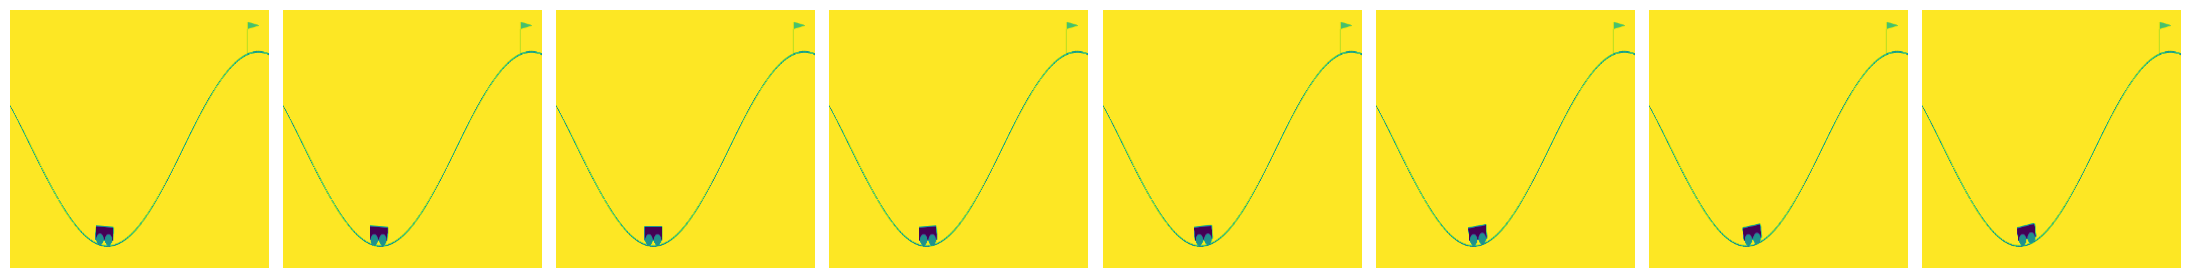

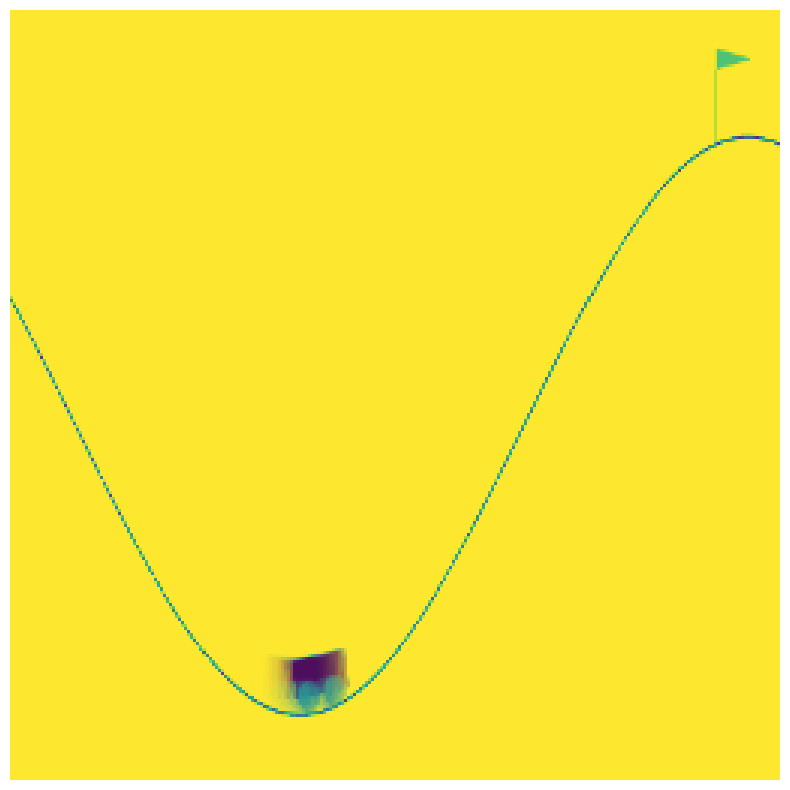

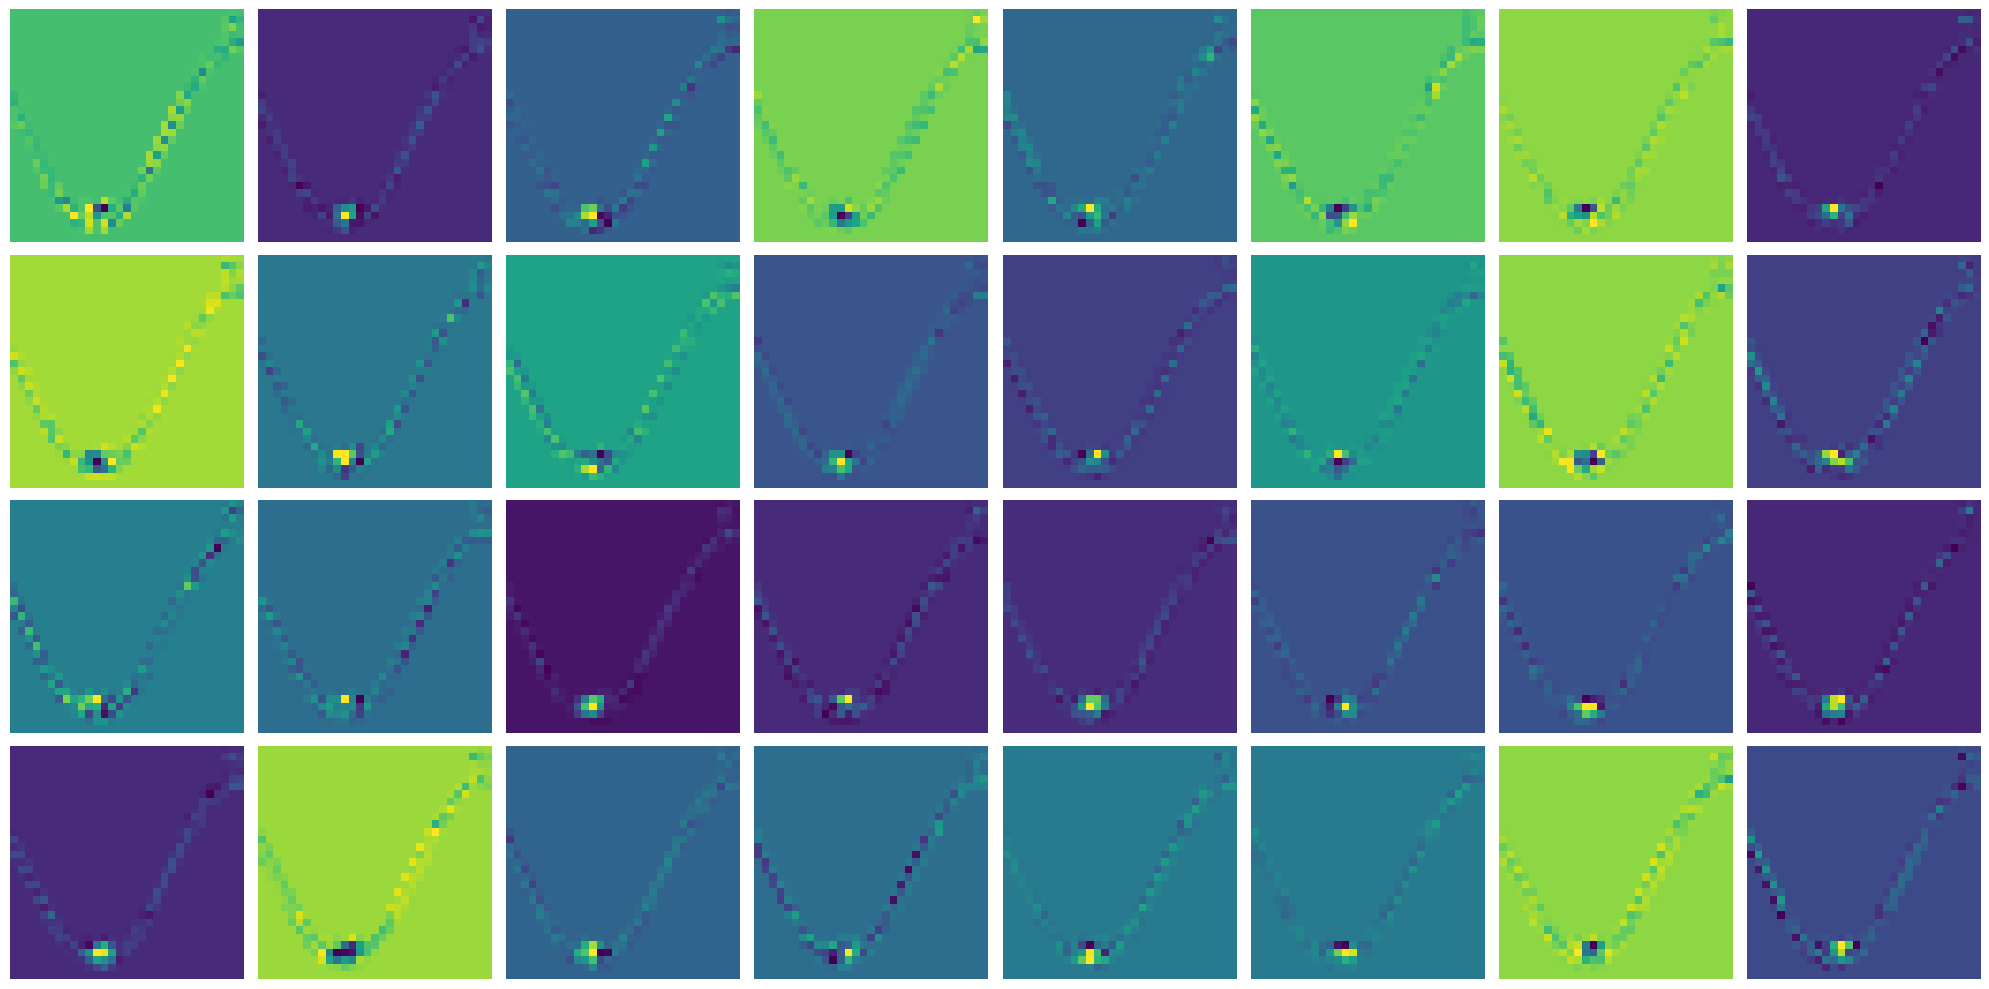

In [68]:
obs = df.state[62]

plot_obs(obs)
plot_obs_overlap(obs)

chosen_layer = "layer3"
layer_features = extract_feature(obs)
layer_features.keys()

nrow = layer_features[chosen_layer].numpy().shape[1]
ncol = np.ceil(nrow/4)
fig, ax = plt.subplots(4, ncol.astype(int), figsize=(20, 10))

for id in range(nrow):
    feature_map = layer_features[chosen_layer][0, id].detach().cpu().numpy()
    ax[int(id/ncol), int(id%ncol)].imshow(feature_map, cmap="viridis")
    ax[int(id/ncol), int(id%ncol)].axis("off")

actions, _ = model.predict(obs)
actions = np.squeeze(actions)

plt.tight_layout()
